In [1]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

MG_imports = {
    'ESN': {
        'net_wide': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-29_BL_dist_decay_net_wide.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_fixed_decay_net_wide.p"}
        },
        'per_cluster': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_dist_decay_per_cluster.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_BL_fixed_decay_per_cluster.p"}
        }
    },
    'DDN':{
        'net_wide': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_dist_decay_net_wide.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_fixed_decay_net_wide.p"}
        },
        'per_cluster': {
            'dd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_dist_decay_per_cluster.p"},
            'fd': {'path': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results_MG/2025-04-24_DDN_fixed_decay_per_cluster.p"}
        }
    }
}

max_gen = 150


# Validation Scores
Import and plot validation performances and hyperparameters

In [2]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            with open(MG_imports[net_type][task_type][het_type]['path'], 'rb') as f:
                MG_imports[net_type][task_type][het_type]['results_dict'] = pkl.load(f)
                print(MG_imports[net_type][task_type][het_type]['results_dict'].keys())
                print(MG_imports[net_type][task_type][het_type]['results_dict']['alpha grid'])

dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation performance', 'parameters', 'evolutionary strategy', 'cma stds', 'error margin', 'number of sequences', 'number of samples', 'alpha grid', 'tau range', 'start value range', 'example net'])
[1e-08, 1e-06, 0.0001, 0.01, 1]
dict_keys(['validation p

In [3]:
np.shape(MG_imports["DDN"]['net_wide']['dd']['results_dict']['validation performance'])

(200, 20, 5)

In [4]:
def MG_plot_df_from_evo_dict(dict, max_gen):
    df_dict = {
        'Generation' : [],
        'Prediction Horizon' : []
    }
    best_i = np.argmax(np.mean(dict['validation performance'][:max_gen, :, :], axis=-1),axis=-1)
    plot = []
    for ind, i in enumerate(best_i):
        plot.append(dict['validation performance'][ind, i, :])
    plot = np.array(plot)
    print(f"Shape of plot: {plot.shape}")
    for gen, pop in enumerate(plot):
        print(pop.shape)
        df_dict['Generation'] += list(np.repeat(gen, pop.shape))
        df_dict['Prediction Horizon'] += list(pop)
    df_plot = pd.DataFrame.from_dict(df_dict)
    return df_plot

In [5]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            dict = MG_imports[net_type][task_type][het_type]['results_dict']
            plot_df = MG_plot_df_from_evo_dict(dict, max_gen)
            MG_imports[net_type][task_type][het_type]['evo_df'] = plot_df

Shape of plot: (150, 5)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
Shape of plot: (150, 5)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5

(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
Shape of plot: (150, 5)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(5,)
(

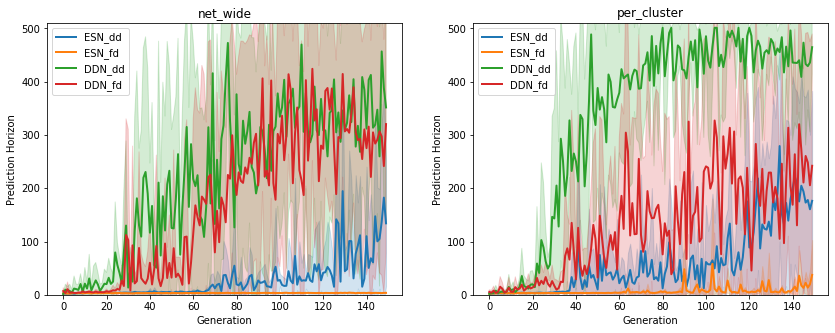

In [6]:
fig, ax= plt.subplots(1, 2, figsize=(14,5))
for net_type in MG_imports:
    for sp, task_type in enumerate(MG_imports[net_type]):
        ax[sp].set_title(task_type)
        ax[sp].set_ylim(0, 510)

        for het_type in MG_imports[net_type][task_type]:
            df_to_plot = MG_imports[net_type][task_type][het_type]['evo_df']
            plot_name = net_type + "_" + het_type
            sns.lineplot(df_to_plot, x='Generation', y='Prediction Horizon', ax=ax[sp], linewidth=2, linestyle="-",label=plot_name, errorbar='sd')

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)


## Basic runs
Just standard ESN and DDN in fixed tau condition, as in chapter 3

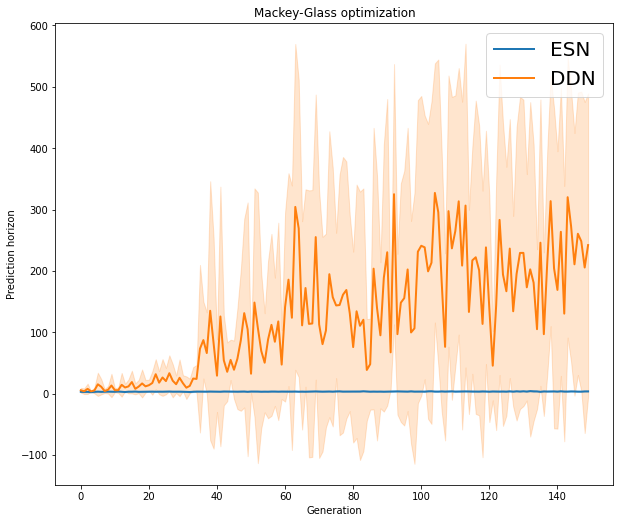

In [15]:
esn_df = MG_imports['ESN']['net_wide']['fd']['evo_df']
ddn_df = MG_imports['DDN']['per_cluster']['fd']['evo_df']
fig, ax= plt.subplots(figsize=(10,8.5))
sns.lineplot(esn_df, x='Generation', y='Prediction Horizon', ax=ax, linewidth=2, linestyle="-",label="ESN", errorbar='sd')
sns.lineplot(ddn_df, x='Generation', y='Prediction Horizon', ax=ax, linewidth=2, linestyle="-",label="DDN", errorbar='sd')
# sns.lineplot(DDN_plot, ax=ax, linewidth=2, linestyle="-", label="DDN")
# sns.lineplot(ADDN_plot, ax=ax, linewidth=2, linestyle="-", label="ADDN")
# plt.xlim(0,200)
plt.xlabel('Generation')
plt.ylabel('Prediction horizon')
plt.title('Mackey-Glass optimization')
ax.legend(fontsize=20)

# Test
Import and plot test performances

In [7]:
test_files_path = "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/test_results_MG/"

In [8]:
for net_type in MG_imports:
    for task_type in MG_imports[net_type]:
        for het_type in MG_imports[net_type][task_type]:
            val_path = MG_imports[net_type][task_type][het_type]['path'].split('/')[-1].split('.')[0]
            test_path = test_files_path+ val_path + "_gen150_test_optimized.p"
            with open(test_path, 'rb') as f:
                MG_imports[net_type][task_type][het_type]['test_dict'] = pkl.load(f)
                print(MG_imports[net_type][task_type][het_type]['test_dict'])


[[92, 182, 141, 140, 84], [59, 130, 103, 37, 31], [119, 155, 204, 151, 137], [103, 204, 127, 41, 203], [81, 213, 127, 72, 156], [33, 19, 30, 9, 19], [64, 45, 55, 75, 44], [14, 15, 0, 2, 6], [139, 74, 40, 75, 116], [214, 76, 114, 94, 53], [95, 45, 55, 70, 11], [71, 163, 152, 33, 36], [255, 160, 320, 122, 413], [116, 102, 90, 136, 83], [168, 264, 198, 271, 175], [19, 58, 37, 7, 56], [205, 173, 216, 89, 168], [43, 64, 133, 44, 109], [72, 320, 186, 191, 86], [52, 130, 106, 39, 165], [53, 1, 55, 1, 28], [90, 210, 166, 44, 157], [35, 81, 33, 36, 43], [26, 66, 4, 1, 32], [134, 138, 157, 112, 94], [47, 34, 17, 61, 47], [75, 120, 80, 145, 58], [68, 26, 27, 31, 31], [59, 126, 184, 62, 47], [22, 10, 28, 18, 19], [111, 147, 170, 71, 164], [32, 72, 69, 4, 48], [157, 285, 184, 263, 362], [140, 209, 131, 132, 162], [10, 1, 2, 3, 2], [24, 38, 106, 201, 129], [38, 26, 40, 22, 30], [104, 136, 85, 29, 53], [230, 241, 170, 158, 64], [47, 18, 74, 17, 20], [25, 64, 43, 40, 70], [148, 175, 256, 148, 250], [4

## Single Tau task

ESN dd
[43, 64, 133, 44, 109]
ESN fd
[2, 1, 2, 1, 1]
DDN dd
[5, 12, 4, 5, 5]
DDN fd
[41, 51, 39, 19, 75]


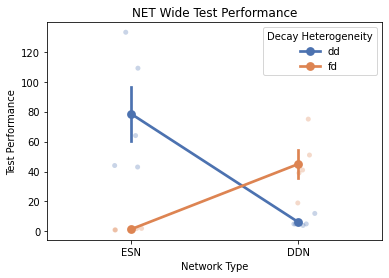

In [9]:
test_dict_pd = {
    'Network Type': [],
    'Decay Heterogeneity': [],
    'Test Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['net_wide']:
        test_dict = MG_imports[net_type]['net_wide'][het_type]['test_dict']
        test_data = test_dict[17]
        print(net_type, het_type)
        print(test_data)
        test_data = test_data
        
        n_samples = len(test_data)
        test_dict_pd['Test Performance'] += test_data
        test_dict_pd['Network Type'] += [net_type] * n_samples
        test_dict_pd['Decay Heterogeneity'] += [het_type] * n_samples

test_pd = pd.DataFrame.from_dict(test_dict_pd)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', errorbar='se', y='Test Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', legend=False, alpha=0.3, palette='deep')
plt.title('NET Wide Test Performance')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_net_wide_test_performance.pdf', dpi=300, bbox_inches='tight')

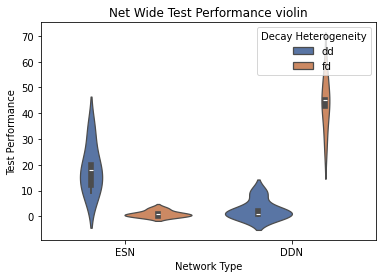

In [74]:
sns.violinplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', palette='deep')
# plt.ylim(0, 100)
plt.title('Net Wide Test Performance violin')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_net_wide_test_performance_violin.pdf', dpi=300, bbox_inches='tight')    

ESN dd
[201, 147, 105, 91, 89]
[201, 147, 105, 91, 89]
ESN fd
[1, 0, 0, 0, 0]
[1, 0, 0, 0, 0]
DDN dd
[347, 384, 435, 378, 496]
[347, 384, 435, 378, 496]
DDN fd
[56, 42, 44, 69, 66]
[56, 42, 44, 69, 66]


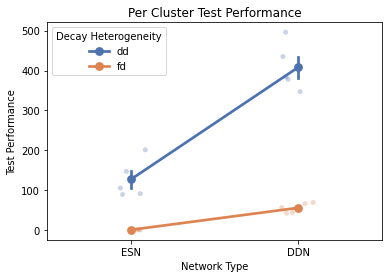

In [10]:
test_dict_pd = {
    'Network Type': [],
    'Decay Heterogeneity': [],
    'Test Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['per_cluster']:
        test_dict = MG_imports[net_type]['per_cluster'][het_type]['test_dict']
        test_data = test_dict[17]
        print(net_type, het_type)
        print(test_data)
        test_data = test_data
        print(test_data)
        n_samples = len(test_data)
        test_dict_pd['Test Performance'] += test_data
        test_dict_pd['Network Type'] += [net_type] * n_samples
        test_dict_pd['Decay Heterogeneity'] += [het_type] * n_samples

test_pd = pd.DataFrame.from_dict(test_dict_pd)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', errorbar='se', y='Test Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', legend=False, alpha=0.3, palette='deep')
# plt.title('Test Fixed Tau')
plt.title('Per Cluster Test Performance')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_per_cluster_test_performance.pdf', dpi=300, bbox_inches='tight')

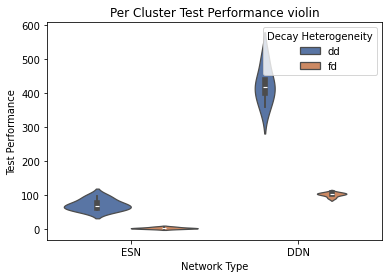

In [76]:
sns.violinplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', palette='deep')
# plt.ylim(0, 100)
# plt.title('Test Fixed Tau')
plt.title('Per Cluster Test Performance violin')
plt.savefig('G:/My Drive/Data For Publication/paper3/figs_MG/MG_per_cluster_test_performance_violin.pdf', dpi=300, bbox_inches='tight')